In [4]:
from dotenv import load_dotenv
import os
import pandas as pd

In [5]:
from openai import OpenAI
# client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [6]:
data = pd.read_csv("../data/11-1_뉴스정제.csv")


In [7]:
doc_list = data ['정제본문'].head(30).tolist()
doc_list[:10]

['서울 연합뉴스 현대백화점그룹이 광주광역시에 서울 여의도 더현대 서울 과 같은 문화복합몰을 만든다고 6일 밝혔다',
 '전주 뉴시스 김얼 기자 이스타항공 자금 배임 횡령으로 전주교도소에 수감됐었던 이상직 전 의원이 30일 전북 전주시 전주교도소에서 보석으로 석방돼 기자들의 질의에 답변하고 있다 2022 06 30 pmkeul newsis com 서울 뉴시스 박정규 기자 이스타항공이 지난 30일 출소한 이상직 전 국회의원에 대해 이스타항공과 전혀 무관한 관계 라고 강조하면서 오해를 야기할 수 있는 언동을 하지 말 것을 경고했다 이스타항공은 3일 설명자료를 내고 현재까지도 이스타항공이 이 전 의원과 관계 있다고 오해될 여지가 있어 전혀 무관함을 분명히 하고자 한다 며 이같이 밝혔다 앞서 이 전 의원은 법원의 보석 허가로 전주교도소에서 출소하는 과정에서 취재진들에게 이스타항공이 좋은 회사가 되게끔 하겠다 며 해고된 직원들이 다시 취업하도록 돕겠다는 취지의 발언을 한 바 있다 이에 대해 이스타항공은 단순히 부적절한 정도를 넘어 새롭게 탈바꿈을 하고 재운항을 준비하고 있는 이스타항공의 진정성 있는 노력에 대내외적 불신을 야기할 수 있는 매우 심각한 문제 라며 향후 이스타항공과 관련이 있는 것으로 오해가 될 수 있는 어떠한 언동도 금해주시기를 요청드린다 고 밝혔다 또 다시 이러한 일이 발생할 경우 재발방지를 위한 모든 조치를 강구할 것임을 분명히 밝힌다 고 덧붙였다 이스타항공은 서울회생법원으로부터 인가된 회생계획에 따라 기존 최대주주인 이스타홀딩스 보유주식을 포함한 구주 전체가 소각됐다 면서 이 전 의원 측은 서울회생법원의 회생절차에서 어떠한 관여도 할 수 없었으며 회생계획에 따른 구주 전체의 무상소각 이후 이스타항공의 주식을 단 1주도 보유하고 있지 않은 이스타항공과 전혀 무관한 관계 라고 선을 그었다 아울러 이스타항공을 인수한 주식회사 성정 또한 이 전 의원과 전혀 관계가 없으며 특히 형남순 회장을 비롯한 관계인 그 누구도 이 전 의원과 일면식조차 없다 고 강조했다

In [8]:
import time

start = time.time()
doc_response = client.embeddings.create(model='text-embedding-3-small',input=doc_list)
api_time = time.time() -start
print(api_time)

NameError: name 'client' is not defined

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
doc_response.data[0].embedding

[-0.020660400390625,
 -0.0028591156005859375,
 0.034210205078125,
 0.034271240234375,
 0.01126861572265625,
 0.0037384033203125,
 0.0038433074951171875,
 0.0570068359375,
 -0.0007305145263671875,
 -0.059722900390625,
 -0.034515380859375,
 -0.0190277099609375,
 0.0014085769653320312,
 -0.04046630859375,
 0.0245513916015625,
 -0.011505126953125,
 -0.004791259765625,
 -0.0009984970092773438,
 0.0478515625,
 -0.012451171875,
 -0.0214691162109375,
 -0.02880859375,
 0.01332855224609375,
 0.006488800048828125,
 -0.007358551025390625,
 -0.018646240234375,
 0.01395416259765625,
 0.0479736328125,
 -0.0010051727294921875,
 -0.01537322998046875,
 -0.03497314453125,
 -0.03692626953125,
 0.0318603515625,
 0.015472412109375,
 0.0149078369140625,
 0.0260772705078125,
 0.0093994140625,
 0.0213623046875,
 0.0309295654296875,
 -0.00678253173828125,
 0.03057861328125,
 -0.006877899169921875,
 0.003173828125,
 0.004497528076171875,
 0.0196990966796875,
 0.0259857177734375,
 -0.0028095245361328125,
 0.00177

In [ ]:
# api_doc_vecs  = []

# for i in doc_response.data:
#     api_doc_vecs.append(i.embedding)

api_doc_vecs =[d.embedding for d in doc_response.data]

query = "우리 집 아파트는 언제 오르나요?"
api_response = client.embeddings.create(model="text-embedding-3-small",input=query)
api_response

CreateEmbeddingResponse(data=[Embedding(embedding=[-0.0177764892578125, -0.0654296875, 0.022125244140625, -0.022918701171875, -0.003833770751953125, -0.01068115234375, -0.04693603515625, -0.0345458984375, -0.00611114501953125, -0.050323486328125, -0.0230865478515625, 0.004955291748046875, 0.00421905517578125, -0.03619384765625, 0.0015506744384765625, 0.037445068359375, -0.004276275634765625, 0.0189971923828125, -0.050445556640625, -0.01812744140625, 0.0236053466796875, -0.0222625732421875, -0.04254150390625, -0.0389404296875, -0.01425933837890625, -0.0244598388671875, 0.03271484375, 0.00803375244140625, 0.0078582763671875, 0.0255889892578125, -0.041351318359375, -0.040557861328125, 0.056182861328125, 0.056884765625, -0.0070037841796875, 0.018798828125, 0.026580810546875, -0.04632568359375, -0.0255279541015625, -0.041015625, -0.004978179931640625, 0.0022430419921875, 0.0243072509765625, 0.04803466796875, -0.0159912109375, 0.076416015625, -0.0292205810546875, 0.0228271484375, 0.012252807

In [ ]:
api_query_vec = [api_response.data[0].embedding]
api_query_vec

[[-0.0177764892578125,
  -0.0654296875,
  0.022125244140625,
  -0.022918701171875,
  -0.003833770751953125,
  -0.01068115234375,
  -0.04693603515625,
  -0.0345458984375,
  -0.00611114501953125,
  -0.050323486328125,
  -0.0230865478515625,
  0.004955291748046875,
  0.00421905517578125,
  -0.03619384765625,
  0.0015506744384765625,
  0.037445068359375,
  -0.004276275634765625,
  0.0189971923828125,
  -0.050445556640625,
  -0.01812744140625,
  0.0236053466796875,
  -0.0222625732421875,
  -0.04254150390625,
  -0.0389404296875,
  -0.01425933837890625,
  -0.0244598388671875,
  0.03271484375,
  0.00803375244140625,
  0.0078582763671875,
  0.0255889892578125,
  -0.041351318359375,
  -0.040557861328125,
  0.056182861328125,
  0.056884765625,
  -0.0070037841796875,
  0.018798828125,
  0.026580810546875,
  -0.04632568359375,
  -0.0255279541015625,
  -0.041015625,
  -0.004978179931640625,
  0.0022430419921875,
  0.0243072509765625,
  0.04803466796875,
  -0.0159912109375,
  0.076416015625,
  -0.029

In [ ]:
api_sim = cosine_similarity(api_query_vec, api_doc_vecs)
api_sim

array([[ 0.12344549,  0.07612205,  0.17595955,  0.15439471,  0.07907581,
         0.05586888,  0.30266432,  0.00196064,  0.15796446,  0.04465145,
         0.0444624 ,  0.04524953,  0.06272936,  0.0174554 ,  0.00260002,
         0.05671117,  0.11455706,  0.14134525,  0.05723644,  0.11367881,
         0.14999793,  0.09568282,  0.0869406 ,  0.17398065,  0.16228086,
        -0.01307989,  0.22482404,  0.03279508,  0.00966954,  0.19379615]])

In [ ]:
api_rank = api_sim.argsort(descending=True)[:3]
api_rank

array([[ 6, 26, 29,  2, 23, 24,  8,  3, 20, 17,  0, 16, 19, 21, 22,  4,
         1, 12, 18, 15,  5, 11,  9, 10, 27, 13, 28, 14,  7, 25]])

In [ ]:
data['정제본문'][[6,26,29]]

6     교통 호재가 있는 곳에 아파트 분양이 이어지고 있어 주목을 받고 있습니다 주 한라가...
26    선제진입한 대우 롯데이어 시공능력 1 2위 삼성 현대 합류 현대엔지니어링 포스코건설...
29    경제와이드 모닝벨 조간 브리핑 장연재 조간브리핑입니다 발길 끊는 개미들 거래대금 2...
Name: 정제본문, dtype: str

- 주제 정해서 문서 수집
- 질문 할 겨우 유사 문서 가져오도록 코드 작성
- 로컬 모델 및 openai 모델 차이 비교 후 문서 정제 등에 대해서 어떻게 할지 고민
- 결과가 이상하다면 질문 자체를 수정해보거나 더 구체적인 질문의 필요성이 높음

In [9]:
df1 = pd.read_csv(
    "../data/오피스텔(전월세)_실거래가_20260914163700.csv",
    encoding="cp949",
    skiprows=15
)

df1.tail()


C:\Users\Lee\AppData\Local\Temp\ipykernel_28124\3226719763.py:1: DtypeWarning: Columns (0: 월세금(만원), 1: 종전계약 월세(만원)) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv(


,NO,시군구,번지,본번,부번,단지명,전월세구분,전용면적(㎡),계약년월,계약일,보증금(만원),월세금(만원),층,건축년도,도로명,계약기간,계약구분,갱신요구권 사용,종전계약 보증금(만원),종전계약 월세(만원)
92517,92518,서울특별시 강서구 등촌동,656-37,656,37,한빛어반뉴스토리,월세,27.80,202509,15,"21,370",15,16,2017.0,공항대로45길 33,202511~202711,신규,-,NaN,NaN
92518,92519,서울특별시 강서구 등촌동,820,820,0,경동미르웰 양천향교 101동,월세,14.33,202509,15,"12,040",15,9,2017.0,강서로68길 35,202509~202709,갱신,-,"15,040",0.0
92519,92520,서울특별시 강서구 등촌동,820,820,0,경동미르웰 양천향교 101동,월세,14.33,202509,15,"5,000",53,7,2017.0,강서로68길 35,202510~202610,갱신,사용,"5,000",47.0
92520,92521,서울특별시 강서구 등촌동,820,820,0,경동미르웰 양천향교 101동,월세,14.33,202509,15,"13,040",10,9,2017.0,강서로68길 35,202509~202709,갱신,-,"15,040",0.0
92521,92522,서울특별시 강서구 등촌동,648-6,648,6,비원오피스텔,월세,40.37,202509,15,"1,000",70,11,2004.0,공항대로 525,202509~202709,신규,-,NaN,NaN


In [ ]:

# print(df1.shape)
# print(df1.columns.tolist())
df1.dtypes


NO                int64
시군구                 str
번지                  str
본번                int64
부번                int64
단지명                 str
전월세구분               str
전용면적(㎡)         float64
계약년월              int64
계약일               int64
보증금(만원)             str
월세금(만원)          object
층                 int64
건축년도            float64
도로명                 str
계약기간                str
계약구분                str
갱신요구권 사용            str
종전계약 보증금(만원)        str
종전계약 월세(만원)      object
dtype: object

In [11]:
from sentence_transformers import SentenceTransformer
#   이제 문서 임베딩을 생성합니다.
local_model = SentenceTransformer(
  "dragonkue/BGE-m3-ko",
  device="cpu"
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [12]:
search_cols = [
"시군구",
"단지명",
"전월세구분",
"전용면적(㎡)",
"보증금(만원)",
"월세금(만원)",
"층",
"도로명"
]

df1["검색문서"] = (
df1[search_cols]
.fillna("")
.astype(str)
.agg(" ".join, axis=1)
)
test_df = df1.head(100).copy()

doc_vectors = local_model.encode(
    test_df["검색문서"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True
)


print(doc_vectors.shape)

(100, 1024)


In [13]:
from sklearn.metrics.pairwise import cosine_similarity

In [15]:
#  질문을 입력하고 유사한 매물을 검색합니다.

query = "광진구 월세 찾아줘"

query_vector = local_model.encode(
      [query],
      convert_to_numpy=True,
      normalize_embeddings=True
  )

similarity = cosine_similarity(query_vector, doc_vectors)[0]
top_indices = similarity.argsort()[::-1][:20]

df1.iloc[top_indices][
    ["시군구", "단지명", "전월세구분", "보증금(만원)", "월세금(만원)", "전용면적(㎡)"]
]


#   단, 보증금이나 월세처럼 숫자 조건은 임베딩보다 Pandas 필터링이 더 정확합니다. 예를 들어 월세
#   80만 원 이하는 다음처럼 처리합니다.


,시군구,단지명,전월세구분,보증금(만원),월세금(만원),전용면적(㎡)
11,서울특별시 광진구 화양동,화양 디펠리체,월세,"1,000",84,20.45
10,서울특별시 광진구 구의동,구의동 벨라로사 오피스텔,월세,"19,500",3,20.94
67,서울특별시 강동구 천호동,은슬림,월세,"9,007",23,30.31
38,서울특별시 영등포구 당산동5가,당산역해링턴타워,월세,500,94,23.92
65,서울특별시 강동구 성내동,(244-4),월세,"18,375",3,29.96
52,서울특별시 강동구 천호동,(287-5),월세,"8,000",15,17.22
23,서울특별시 성북구 삼선동4가,성신다빈치,월세,"23,000",10,17.72
68,서울특별시 강동구 천호동,은슬림,월세,"11,255",11,30.31
95,서울특별시 금천구 독산동,SHIN YOUNG,월세,"19,332",16,55.93
94,서울특별시 금천구 독산동,SHIN YOUNG,월세,"18,205",15,55.93


In [19]:
import pandas as pd
df1["월세금_숫자"] = pd.to_numeric(
    df1["월세금(만원)"]
    .astype(str)
    .str.replace(",", ""),
    errors="coerce"
)

# result = df1[df1["월세금_숫자"] <= 80]

result[
    ["시군구", "단지명", "보증금(만원)", "월세금(만원)", "월세금_숫자"]
].sort_values(by='보증금(만원)',ascending=False)[:20]


,시군구,단지명,보증금(만원),월세금(만원),월세금_숫자
19836,서울특별시 강서구 마곡동,마곡나루역보타닉푸르지오시티,990,79,79
17023,서울특별시 양천구 목동,목동 현대 하이페리온2,"99,750",0,0
37705,서울특별시 양천구 목동,목동 현대 하이페리온2,"99,750",0,0
67910,서울특별시 양천구 목동,목동 굿모닝탑,"99,750",0,0
13552,서울특별시 양천구 목동,목동파라곤,"98,700",0,0
26652,서울특별시 양천구 목동,현대하이페리온,"98,000",0,0
16616,서울특별시 강남구 청담동,(46-3),970,67,67
35058,서울특별시 강남구 도곡동,타워팰리스,"97,000",0,0
2580,서울특별시 성동구 용답동,(238-5),967,28,28
3292,서울특별시 성동구 용답동,(238-5),967,28,28


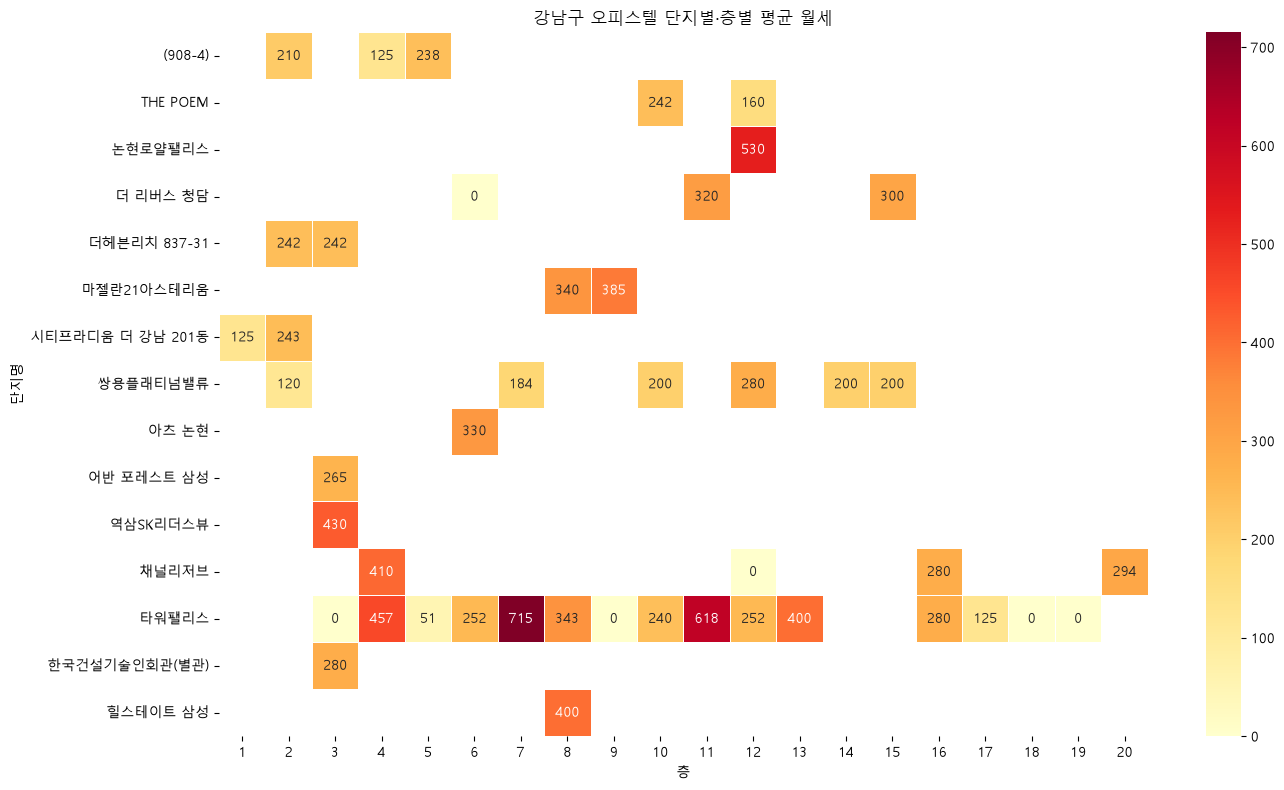

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"

gangnam = df1[
    df1["시군구"].str.contains("강남구", na=False)
].copy()

gangnam["월세금_숫자"] = pd.to_numeric(
    gangnam["월세금(만원)"]
    .astype(str)
    .str.replace(",", ""),
    errors="coerce"
)

gangnam["층_숫자"] = pd.to_numeric(
    gangnam["층"],
    errors="coerce"
)

# 월세 평균이 높은 단지 15개 선택
top_complexes = (
    gangnam.groupby("단지명")["월세금_숫자"]
    .mean()
    .nlargest(15)
    .index
)

heatmap_data = (
    gangnam[gangnam["단지명"].isin(top_complexes)]
    .pivot_table(
        index="단지명",
        columns="층_숫자",
        values="월세금_숫자",
        aggfunc="mean"
    )
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("강남구 오피스텔 단지별·층별 평균 월세")
plt.xlabel("층")
plt.ylabel("단지명")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
plot_df = gangnam.copy()

plot_df["전용면적_숫자"] = pd.to_numeric(
plot_df["전용면적(㎡)"],
errors="coerce"
)

plot_df["보증금_숫자"] = pd.to_numeric(
plot_df["보증금(만원)"]
.astype(str)
.str.replace(",", ""),
errors="coerce"
)

plot_df = plot_df.dropna(
subset=["전용면적_숫자", "월세금_숫자", "보증금_숫자"]
)


fig = px.scatter(
    plot_df,
    x="전용면적_숫자",
    y="월세금_숫자",
    color="단지명",
    size="보증금_숫자",
    hover_data=[
        "단지명",
        "시군구",
        "전월세구분",
        "보증금(만원)",
        "월세금(만원)",
        "층",
        "계약년월",
        "도로명"
    ],
    labels={
        "전용면적_숫자": "전용면적(㎡)",
        "월세금_숫자": "월세금(만원)",
        "보증금_숫자": "보증금(만원)"
    },
    title="강남구 오피스텔 전용면적과 월세 관계"
)

fig.show()

In [ ]:
1. 주제 정하기
다음 주제 중 하나를 선택합니다.

대중교통: 버스 노선, 지하철 이용 안내
관광: 지역별 관광지, 여행 코스
음식: 음식점 메뉴, 영양 정보
공공시설: 도서관, 체육관, 주민센터 안내
환경: 미세먼지, 재활용, 기후 정보
교육: 학교 안내, 장학금, 교육 과정
재난안전: 재난 행동 요령, 응급처치 방법
직접 문서를 작성하거나 공공데이터포털에서 관련 자료 를 수집합니다.

2. 질문과 유사한 문서 찾기
사용자가 질문을 입력하면 문서 임베딩과 질문 임베딩 의 유사도를 비교하여 관련 문서를 가져옵니다.

예시:

질문: 서울에서 지하철을 이용할 때 환승 할인은 어떻게 적용 되나요?

가져올 문서:

수도권 지하철 환승 할인 안내
교통카드 이용 방법
지하철 요금 기준
3. 임베딩 모델 비교하기
같은 문서를 사용하여 다음 두 모델의 결과를 비교합니 다.

로컬 임베딩 모델
OpenAI 임베딩 모델
비교할 내용:

비슷한 문서를 잘 찾는가?
처리 속도는 어떤가?
비용이 발생하는가?
한국어 질문을 얼마나 잘 이해하는가?
문서의 제목과 내용이 검색 결과에 영향을 주는가?
4. 문서 정제하기
검색 결과가 이상하면 문서를 다음과 같이 정리해 봅니 다.

불필요한 기호와 공백 제거
문서 제목과 본문 분리
너무 긴 문서를 작은 단락으로 나누기
표나 메뉴 정보를 문장 형태로 바꾸기
문서마다 비슷한 형식으로 통일하기
5. 구체적인 질문 만들기
모호한 질문보다 조건을 포함한 질문이 더 좋습니다.

나쁜 질문: 교통카드 알려줘

좋은 질문: 서울 지하철에서 교통카드로 환승할 때 할인 조건과 적 용 시간을 알려줘

나쁜 질문: 제주도 여행지는?

좋은 질문: 제주도에서 대중교통으로 이동하기 좋은 자연 관광지 3 곳을 추천해줘

최종 목표
선택한 주제의 문서를 수집하고, 사용자의 구체적인 질 문과 가장 유사한 문서를 찾아 출력하는 검색 프로그램 을 완성합니다.